## AY25-26 Term 2 CS421 Group Project

In [2]:
import numpy as np
import pandas as pd
data=np.load("training_batch_with_labels.npz")
print(data)

NpzFile 'training_batch_with_labels.npz' with keys: X, y


In [3]:
X=data["X"]
y=data["y"]

print("# of interactions:", X.shape[0])
print("# of anomalous and normal users:", np.count_nonzero(y==1), np.count_nonzero(y==0))


df=pd.DataFrame(X)
labels=pd.DataFrame(y)
df.rename(columns={0:"user",1:"item",2:"rating"},inplace=True)
print("# of items:", df['item'].unique().shape[0])

# of interactions: 177346
# of anomalous and normal users: 100 1000
# of items: 993


In [4]:
df.head(100)

,user,item,rating
0,304,0,3
1,304,1,3
2,304,14,3
3,304,17,4
4,304,19,4
...,...,...,...
95,304,824,3
96,304,826,3
97,304,828,4
98,304,847,3


In [5]:
labels.rename(columns={0:"user",1:"label"},inplace=True)

In [6]:
labels.head(10)

,user,label
0,100,0
1,101,0
2,102,0
3,103,0
4,104,0
5,105,0
6,106,0
7,107,0
8,108,0
9,109,0


In [7]:
labels.to_csv('ground_truth.csv', index=False, header=False)

In [8]:
## Example with random scores
data_pred=np.load("subset_training_batch.npz")
X_pred=data_pred["X"]
n_users = len(np.unique(X_pred[:, 0]))
print(f'No of users : {n_users}')

No of users : 220


## Feature Engineering

The objective is to derive user-level behavioural features from the interaction dataset (user, item, rating) so that the model can learn behavioural patterns that distinguish anomalous users from normal users.

Since anomaly detection occurs at the user level, all features must summarize a user's rating behaviour across items.

In [47]:
# Check for null values
df.isnull().sum()
# Identify if a user has repeatedly rated the same item
repeat_counts = df.groupby(["user", "item"]).size()
repeated = repeat_counts[repeat_counts > 1]
repeated

df = df.groupby(["user", "item"])["rating"].mean().reset_index()

user_stats = df.groupby("user")["rating"].agg([
    "mean",
    "std",
    "min",
    "max",
    "count"
]).rename(columns={
    "mean": "user_mean_rating",
    "std": "user_rating_std",
    "min": "user_min_rating",
    "max": "user_max_rating",
    "count": "num_ratings"
})

print(f'# of users with mean ratinng > 4 : {user_stats[user_stats['user_mean_rating'] > 4].shape[0]}')
print(f"Total users: {user_stats.shape[0]}")

# Compute the rating distribution
rating_dist = pd.crosstab(df["user"], df["rating"])
rating_dist.columns = [f"rating_{c}_count" for c in rating_dist.columns]


# Compute the item coverage per user
items_per_user = df.groupby("user")["item"].nunique()
item_coverage = items_per_user / 1000
item_coverage = item_coverage.rename("item_coverage")
item_coverage_df = item_coverage.reset_index()


# Compute item popularity && 
# average popularity per user
#(On average, how popular are the items this user rates?)
item_popularity_df = df.groupby('item')['user'].count().reset_index()
item_popularity_df = item_popularity_df.rename(
    columns={"user": "item_popularity"}
)
df = df.merge(item_popularity_df, on="item", how="left")
user_avg_popularity = (
    df.groupby("user")["item_popularity"]
    .mean()
    .rename("avg_item_popularity")
    .reset_index()
)
user_avg_popularity
# Combine all engineered features
user_features = user_stats.reset_index()
user_features = user_features.merge(
    item_coverage_df, on="user", how="left"
)
user_features = user_features.merge(
    user_avg_popularity, on="user", how="left"
)
user_features = user_features.merge(
    rating_dist.reset_index(), on="user", how="left"
)

user_features = user_features.merge(
    labels, on="user", how="left"
)

user_features
user_features.to_csv('user_features.csv')

# of users with mean ratinng > 4 : 139
Total users: 1100


Now that we have our user behavioural features, we can start builing a baseline model.


In [ ]:
user_features.dtypes
#  Separate Features and labels
X = user_features.drop(columns=["user", "label"])
y = user_features["label"]


from sklearn.model_selection import train_test_split
# Since dataset is imbalanced we startify based on y
# to ensure both train and test set have the same anomaly ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# Perform standardization of features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
# transform only no fitting occurs so that data leakage does not happen
X_test_scaled = scaler.transform(X_test)


from sklearn.linear_model import LogisticRegression

# Balanced weighting increases penalty for misclassifying anomalies.
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

[0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 1 0 0
 0 0 1 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0] 220


In [46]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Anomaly"],
    columns=["Predicted Normal", "Predicted Anomaly"]
)
print("Confusion Matrix:")
print(cm_df)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC-AUC:", roc_auc)

# AUPRC (Average Precision Score)
auprc = average_precision_score(y_test, y_prob)
print("AUPRC:", auprc)

Confusion Matrix:
                Predicted Normal  Predicted Anomaly
Actual Normal                176                 24
Actual Anomaly                 7                 13

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       200
           1       0.35      0.65      0.46        20

    accuracy                           0.86       220
   macro avg       0.66      0.77      0.69       220
weighted avg       0.91      0.86      0.88       220


ROC-AUC: 0.84875
AUPRC: 0.5546043981991247


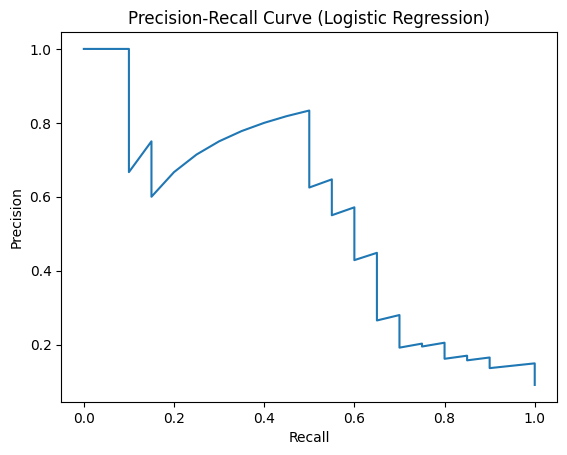

In [34]:
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Logistic Regression)")
plt.show()